# 模型选择、欠拟合和过拟合

## 环境配置


In [1]:
import os
import sys
import warnings
import logging
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
logging.getLogger("matplotlib").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="Cannot create tensor with internal format")
import pypto
import torch
from torch import nn
import torch_npu
from d2l import torch as d2l
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")
import numpy as np

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


## 练习4.4.1

这个多项式回归问题可以准确地解出吗？提示：使用线性代数。

**解答：** 

$$L(w)=\frac{1}{2} \sum_{i=1}^N\left(\sum_{j=0}^M w_j x_i^j-y_i\right)^2$$

$$\text{取} \frac{\partial L(w)}{\partial w_k}=0\Rightarrow\frac{1}{2} \sum_{i=1}^N 2\left(\sum_{j=0}^M w_j x_i^j-y_i\right) \times x_i^k=0 \Rightarrow \sum_{i=1}^N \sum_{j=0}^M w_j x_i^{j+k}=\sum_{i=1}^N x_i^k y_i \quad (k=0,1,2, \cdots, M)$$

令

$$X=\left[\begin{array}{cccc}
\sum_{i=1}^N x_i^0 x_i^0 & \sum_{i=1}^N x_i^0 x_i^1 & \ldots & \sum_{i=1}^N x_i^0 x_i^M \\
\sum_{i=1}^N x_i^1 x_i^0 & \sum_{i=1}^N x_i^1 x_i^1 & \ldots & \sum_{i=1}^N x_i^1 x_i^M \\
\vdots & \vdots & \ddots & \vdots \\
\sum_{i=1}^N x_i^M x_i^0 & \sum_{i=1}^N x_i^M x_i^1 & \ldots & \sum_{i=1}^N x_i^M x_i^M
\end{array}\right]$$

$$W=\left[\begin{array}{c}
w_0 \\
w_1 \\
\vdots \\
w_M
\end{array}\right] \quad Y=\left[\begin{array}{c}
\sum_{i=1}^N x_i^0 y_i \\
\sum_{i=1}^N x_i^1 y_i \\
\vdots \\
\sum_{i=1}^N x_i^M y_i
\end{array}\right]$$

则有 $XW = Y$，从而 $W = X^{-1}Y$，即该问题可以通过矩阵求逆得到精确解。

## 练习4.4.2

考虑多项式的模型选择。
1. 绘制训练损失与模型复杂度（多项式的阶数）的关系图。观察到了什么？需要多少阶的多项式才能将训练损失减少到0?
2. 在这种情况下绘制测试的损失图。
3. 生成同样的图，作为数据量的函数。

**解答：** 

1. 在多项式阶数没有达到4之前阶数增加使得训练损失下降，当阶数超过4时训练损失几乎不变，稳定在0.01这个数量级。

**2. 绘制测试的损失图。**

**解答：** 对比训练损失和测试损失图可以发现，测试损失曲线整体走势与训练损失类似：阶数小于 4 时测试损失下降，阶数等于 4 时达到最低点，阶数超过 4 后测试损失快速上升。不同的是，高阶时测试损失远高于训练损失，这直观地展示了过拟合现象——模型在训练集上表现完美，但在测试集上泛化很差。



以下使用 `torch` 编程进行验证：


In [ ]:
import math
import numpy as np

n_train, n_test = 100, 100  # 训练和测试数据集大小

def train4_4_2(orderlist, n_train, n_test, num_epochs=400, show=True):
    max_degree = 20  # 多项式的最大阶数
    true_w = np.zeros(max_degree)  # 分配大量的空间
    true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

    features = np.random.normal(size=(n_train + n_test, 1))
    np.random.shuffle(features)
    poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
    for i in range(max_degree):
        poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
    # labels的维度:(n_train+n_test,)
    labels = np.dot(poly_features, true_w)
    labels += np.random.normal(scale=0.1, size=labels.shape)
    true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32) 
                                                for x in [true_w, features, poly_features, labels]]
    if show:
        animator = d2l.Animator(xlabel='order', ylabel='log(loss)', yscale='log',
                                xlim=[1, orderlist[-1]], ylim=[1e-3, 1e2],
                                legend=['train', 'test'])
    train_losslist, test_losslist = [], []
    for i in orderlist:
        train_features = poly_features[:n_train, :i]
        test_features = poly_features[n_test:, :i]
        train_labels = labels[:n_train]
        test_labels = labels[n_test:]
        loss = nn.MSELoss(reduction='none')
        input_shape = train_features.shape[-1]
        # 不设置偏置，因为我们已经在多项式中实现了它
        net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
        batch_size = min(10, train_labels.shape[0])
        train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
        test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)),
                                   batch_size, is_train=False)
        trainer = torch.optim.SGD(net.parameters(), lr=0.01)
        for epoch in range(num_epochs):
            d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        train_loss = d2l.evaluate_loss(net, train_iter, loss)
        test_loss = d2l.evaluate_loss(net, test_iter, loss)
        train_losslist.append(train_loss)
        test_losslist.append(test_loss)
        if show:
            animator.add(i, (train_loss, test_loss))
    return train_losslist, test_losslist

train4_4_2(np.arange(1, 21), n_train, n_test, 400)


使用 `PyPTO` 编程进行验证:


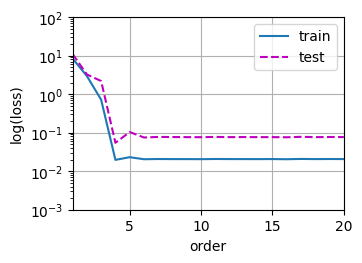

In [2]:
import math
from src.utils import Animator, load_array, train_epoch_ch3, evaluate_loss
from src.pypto_ops import PyPTOLinear, mse_loss

n_train, n_test = 100, 100  # 训练和测试数据集大小

def train4_4_2(orderlist, n_train, n_test, num_epochs=400, show=True):

    max_degree = 20  # 多项式的最大阶数
    true_w = np.zeros(max_degree)  # 分配大量的空间
    true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

    features = np.random.normal(size=(n_train + n_test, 1))
    np.random.shuffle(features)
    poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
    for i in range(max_degree):
        poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
    # labels的维度:(n_train+n_test,)
    labels = np.dot(poly_features, true_w)
    labels += np.random.normal(scale=0.1, size=labels.shape)
    true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32, device=device) for x in [true_w, features, poly_features, labels]]
    if show:
        animator = Animator(xlabel='order', ylabel='log(loss)', yscale='log',
                                xlim=[1, orderlist[-1]], ylim=[1e-3, 1e2],
                                legend=['train', 'test'])
    train_losslist, test_losslist = [], []
    for i in orderlist:
        train_features = poly_features[:n_train, :i]
        test_features = poly_features[n_test:, :i]
        train_labels = labels[:n_train]
        test_labels = labels[n_test:]
        loss = lambda y_hat, y: mse_loss(y_hat, y, reduction='none')
        input_shape = train_features.shape[-1]
        # 不设置偏置，因为我们已经在多项式中实现了它
        net = nn.Sequential(PyPTOLinear(input_shape, 1, bias=False)).to(device)
        batch_size = min(10, train_labels.shape[0])
        train_iter = load_array((train_features, train_labels.reshape(-1,1)),
                                    batch_size)
        test_iter = load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
        trainer = torch.optim.SGD(net.parameters(), lr=0.01)
        for epoch in range(num_epochs):
            train_epoch_ch3(net, train_iter, loss, trainer)
        train_loss = evaluate_loss(net, train_iter, loss)
        test_loss = evaluate_loss(net, test_iter, loss)
        train_losslist.append(train_loss)
        test_losslist.append(test_loss)
        if show:
            animator.add(i, (train_loss, test_loss))
    return train_losslist, test_losslist

train4_4_2(np.arange(1, 21), n_train, n_test, 400);


**3. 生成同样的图，作为数据量的函数。**

**解答：** 从图中可以看出，随着训练数据量增加，相同阶数下训练损失和测试损失之间的差距逐渐缩小。当数据量较小时（如 100），即使是阶数较低的多项式也会出现过拟合；数据量较大时（如接近 1000），高阶多项式的泛化能力明显改善。这表明充足的数据是缓解过拟合的有效手段。


以下使用 `torch` 编程进行验证：


In [ ]:
animator = d2l.Animator(xlabel='datasize', ylabel='log(trainloss)', yscale='log',
                            xlim=[90, 1100], ylim=[1e-3, 1e2],
                            legend=list(map(lambda x: "order {}".format(x), np.arange(1, 21, 5))))
animator2 = d2l.Animator(xlabel='datasize', ylabel='log(testloss)', yscale='log',
                             xlim=[90, 1100], ylim=[1e-3, 1e2],
                             legend=list(map(lambda x: "order {}".format(x), np.arange(1, 21, 5))))
for datasize in range(100, 1100, 100):
    train_losslist, test_losslist = train4_4_2(np.arange(1, 21, 5), datasize, datasize,
                                                num_epochs=400, show=False)
    animator.add(datasize, list(train_losslist))
    animator2.add(datasize, list(test_losslist))


使用 `PyPTO` 编程进行验证:


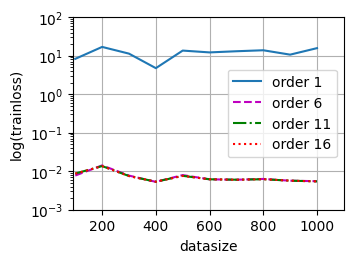

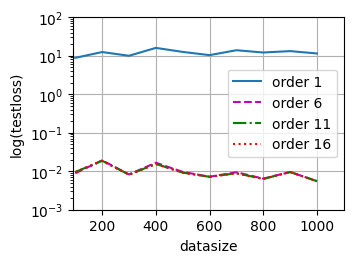

In [3]:
animator = Animator(xlabel='datasize', ylabel='log(trainloss)', yscale='log',
                                xlim=[90, 1100], ylim=[1e-3, 1e2],
                                legend=list(map(lambda x: "order {}".format(x), np.arange(1, 21, 5))))
animator2 = Animator(xlabel='datasize', ylabel='log(testloss)', yscale='log',
                                xlim=[90, 1100], ylim=[1e-3, 1e2],
                                legend=list(map(lambda x: "order {}".format(x), np.arange(1, 21, 5))))
for datasize in range(100, 1100, 100):
    train_losslist, test_losslist = train4_4_2(np.arange(1, 21, 5), datasize, datasize,
                                                num_epochs=400, show=False)
    animator.add(datasize, list(train_losslist))
    animator2.add(datasize, list(test_losslist))


## 练习4.4.3

如果不对多项式特征$x^i$进行标准化（$1/i!$），会发生什么事情？能用其他方法解决这个问题吗？

**解答：** 避免出现较大的梯度值或者损失值。除了这个办法我们也可以让每个特征减去该特征数据的平均值并除以标准差。

## 练习4.4.4

泛化误差可能为零吗？

**解答：** 在训练数据足够多的时候泛化误差接近经验误差，对于确定可解且数据没有噪声的问题，泛化误差可以为零。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
